# E-commerce Sales Data — Cleaning & Analysis

**Goal:** Take a messy real-world e-commerce dataset, clean it thoroughly, and extract actionable business insights through exploratory analysis and visualisations.

**Dataset:** 103 orders with columns for order ID, product, category, quantity, price, payment method, order date, and status.

**Sections:**
1. Data Loading  
2. Initial Inspection  
3. Data Cleaning (10 steps)  
4. Clean Data Validation  
5. Exploratory Analysis  
6. Visualisations  
7. Key Insights & Recommendations

## 1. Data Loading

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Global plot style — clean, minimal, consistent
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860", "#DA8BC3"]

In [3]:
df = pd.read_csv("messy_ecommerce_sales_data.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (103, 11)


,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51


## 2. Initial Inspection

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              103 non-null    int64  
 1    Customer_Name  103 non-null    object 
 2   Order_ID        103 non-null    object 
 3   Order_Date      103 non-null    object 
 4   Product         103 non-null    object 
 5    Category       95 non-null     object 
 6   Quantity        98 non-null     object 
 7   Price           98 non-null     object 
 8   Payment_Method  103 non-null    object 
 9   Status          103 non-null    object 
 10  Total           89 non-null     float64
dtypes: float64(1), int64(1), object(9)
memory usage: 9.0+ KB


**Null value summary from `.info()` output:**

| Column | Null Count |
|---|---|
| Category | 8 |
| Quantity | 5 |
| Price | 5 |
| Total | 14 |

All other columns (ID, Customer_Name, Order_ID, Order_Date, Product, Payment_Method, Status) are complete.

In [9]:
df.describe()

,ID,Total
count,103.000000,89.000000
mean,149.640777,1232.949101
std,28.704326,2605.471455
min,100.000000,-20000.000000
25%,125.500000,582.130000
50%,149.000000,1138.760000
75%,174.500000,2153.400000
max,199.000000,4722.700000


## 3. Data Cleaning

### 3.1  Drop rows where `Total` is missing

Rows without a Total value cannot be used in revenue analysis and are dropped. This reduces the dataset from 103 to 89 records.

In [11]:
df = df.dropna(subset=["Total"])
print(f"Rows after dropping missing Total: {len(df)}")

Rows after dropping missing Total: 89


### 3.2  Strip whitespace from column names

Some column names have leading/trailing spaces (visible when printing `df.columns`), which causes `KeyError` bugs.

In [13]:
print("Before:", df.columns.tolist())
df.columns = df.columns.str.strip()
print("After: ", df.columns.tolist())

Before: ['ID', ' Customer_Name', 'Order_ID', 'Order_Date', 'Product', ' Category', 'Quantity', 'Price', 'Payment_Method', 'Status', 'Total']
After:  ['ID', 'Customer_Name', 'Order_ID', 'Order_Date', 'Product', 'Category', 'Quantity', 'Price', 'Payment_Method', 'Status', 'Total']


### 3.3  Fill missing `Category` values

Rather than dropping these rows, missing categories are labelled `"UNKNOWN"` so they remain in the dataset and are easy to identify later.

In [15]:
df["Category"] = df["Category"].fillna("Unknown")
print("Remaining Category nulls:", df["Category"].isnull().sum())

Remaining Category nulls: 0


### 3.4  Standardise text columns

Inconsistent casing (e.g. `"electronics"` vs `"Electronics"` vs `"ELECTRONICS"`) and leading/trailing spaces cause the same value to appear as multiple distinct entries. Applying `.str.upper().str.strip()` resolves this.

In [17]:
text_cols = ["Category", "Product", "Payment_Method", "Status"]
for col in text_cols:
    df[col] = df[col].str.upper().str.strip()

print("Unique categories:      ", df["Category"].unique())
print("Unique payment methods: ", df["Payment_Method"].unique())
print("Unique statuses:        ", df["Status"].unique())

Unique categories:       ['HOME' 'SPORTS' 'BOOKS' 'CLOTHING' 'ELECTRONICS' 'ELECTRONIC' 'UNKNOWN']
Unique payment methods:  ['CASH ON DELIVERY' 'PAYPAL' 'CREDIT CARD' 'BANK TRANSFER']
Unique statuses:         ['SHIPPED' 'DELIVERED' 'PROCESSING' 'CANCELLED' 'RETURNED']


### 3.5  Fix data types

`Price`, `Quantity`, and `Total` were read as `object` due to mixed formatting in the raw file. Cast them to `float` for arithmetic.

In [19]:
df["Price"]    = df["Price"].astype(float)
df["Quantity"]  = df["Quantity"].astype(float)
df["Total"]     = df["Total"].astype(float)
df.dtypes

ID                  int64
Customer_Name      object
Order_ID           object
Order_Date         object
Product            object
Category           object
Quantity          float64
Price             float64
Payment_Method     object
Status             object
Total             float64
dtype: object

### 3.6  Verify `Total` = `Quantity × Price`

Some rows had incorrect pre-computed totals. Recalculating from source columns ensures consistency.

In [21]:
df["Total"] = df["Quantity"] * df["Price"]
print("Total recalculated from Quantity × Price.")

Total recalculated from Quantity × Price.


### 3.7  Parse `Order_Date` to datetime

The date column is stored as a mixed-format string. Converting to `datetime64` enables time-based analysis.

In [23]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="mixed")
print(df["Order_Date"].dtype)
print(f"Date range: {df['Order_Date'].min().date()}  →  {df['Order_Date'].max().date()}")

datetime64[ns]
Date range: 2023-01-05  →  2025-11-06


### 3.8  Remove duplicate `Order_ID` entries

In [25]:
print("Duplicate Order_IDs before:", df["Order_ID"].duplicated().sum())
df.drop_duplicates(subset=["Order_ID"], inplace=True)
print("Duplicate Order_IDs after: ", df["Order_ID"].duplicated().sum())
print(f"Rows remaining: {len(df)}")

Duplicate Order_IDs before: 3
Duplicate Order_IDs after:  0
Rows remaining: 86


### 3.9  Fix negative `Quantity` values

Negative quantities are data entry errors. `.abs()` converts them to positive values, and `Total` is recalculated afterwards.

In [27]:
negative_before = (df["Quantity"] <= 0).sum()
df["Quantity"] = df["Quantity"].abs()
df["Total"]    = df["Quantity"] * df["Price"]
print(f"Negative quantity rows fixed: {negative_before}")

Negative quantity rows fixed: 2


### 3.10  Fix Category–Product mismatches

Several products were assigned to the wrong category (e.g. `HEADPHONES` under `HOME`) or had a typo in the category name (`ELECTRONIC` instead of `ELECTRONICS`). Correcting these ensures category-level analysis is accurate.

In [29]:
# Fix typo in category name
df["Category"] = df["Category"].replace({"ELECTRONIC": "ELECTRONICS"})

# Reassign products to correct categories
product_category_map = {
    "HEADPHONES":  "ELECTRONICS",
    "SMARTPHONE":  "ELECTRONICS",
    "LAPTOP":      "ELECTRONICS",
    "VACUUM":      "ELECTRONICS",
    "BLENDER":     "ELECTRONICS",
    "JEANS":       "CLOTHING",
    "T-SHIRT":     "CLOTHING",
    "SHOES":       "SPORTS",
    "YOGA MAT":    "SPORTS",
    "BASKETBALL":  "SPORTS",
    "BIOGRAPHY":   "BOOKS",
    "LAMP":        "HOME",
}

for product, category in product_category_map.items():
    df.loc[df["Product"] == product, "Category"] = category

print("Category-product mapping applied.")
print("\nFinal categories:", df["Category"].unique())

Category-product mapping applied.

Final categories: ['ELECTRONICS' 'SPORTS' 'BOOKS' 'HOME' 'CLOTHING']


## 4. Clean Data Validation

A final check to confirm the cleaned dataset has no remaining issues before analysis.

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86 entries, 0 to 99
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID              86 non-null     int64         
 1   Customer_Name   86 non-null     object        
 2   Order_ID        86 non-null     object        
 3   Order_Date      86 non-null     datetime64[ns]
 4   Product         86 non-null     object        
 5   Category        86 non-null     object        
 6   Quantity        86 non-null     float64       
 7   Price           86 non-null     float64       
 8   Payment_Method  86 non-null     object        
 9   Status          86 non-null     object        
 10  Total           86 non-null     float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(6)
memory usage: 8.1+ KB


In [35]:
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Rows ===")
print(df.duplicated().sum(), "duplicate rows")

print("\n=== Negative Quantities ===")
print((df["Quantity"] <= 0).sum(), "rows with quantity ≤ 0")

=== Missing Values ===
ID                0
Customer_Name     0
Order_ID          0
Order_Date        0
Product           0
Category          0
Quantity          0
Price             0
Payment_Method    0
Status            0
Total             0
dtype: int64

=== Duplicate Rows ===
0 duplicate rows

=== Negative Quantities ===
0 rows with quantity ≤ 0


In [37]:
df.describe().round(2)

,ID,Order_Date,Quantity,Price,Total
count,86.00,86,86.00,86.00,86.00
mean,149.91,2025-04-10 10:02:47.441860352,3.01,619.46,1780.13
min,100.00,2023-01-05 00:00:00,1.00,-100.00,-300.00
25%,127.25,2025-01-30 06:00:00,2.00,268.80,669.91
50%,149.50,2025-05-14 00:00:00,3.00,534.70,1300.93
75%,173.75,2025-07-28 00:00:00,4.00,740.40,2377.43
max,199.00,2025-11-06 00:00:00,5.00,10000.00,20000.00
std,28.06,NaN,1.51,1057.62,2315.86


In [39]:
# Save cleaned dataset
df.to_csv("cleaned_ecommerce_data.csv", index=False)
print("Cleaned data saved to cleaned_ecommerce_data.csv")

Cleaned data saved to cleaned_ecommerce_data.csv


## 5. Exploratory Analysis

### 5.1  Basic Overview

In [41]:
# Most common category
print("=== Orders by Category ===")
print(df["Category"].value_counts().to_string())

=== Orders by Category ===
Category
ELECTRONICS    25
SPORTS         22
BOOKS          22
HOME           10
CLOTHING        7


Electronics and Books are tied as the most frequently ordered categories. Clothing has the fewest orders.

In [43]:
# Most used payment method
print("=== Payment Method Usage ===")
print(df["Payment_Method"].value_counts().to_string())

=== Payment Method Usage ===
Payment_Method
CASH ON DELIVERY    29
PAYPAL              20
BANK TRANSFER       19
CREDIT CARD         18


Cash on Delivery is the most popular payment method, followed by PayPal. Credit Card is the least used.

In [45]:
# Order status breakdown
print("=== Order Status Breakdown ===")
print(df["Status"].value_counts().to_string())

=== Order Status Breakdown ===
Status
RETURNED      24
SHIPPED       20
PROCESSING    20
CANCELLED     12
DELIVERED     10


A notable portion of orders have been returned — this is explored further in Section 5.3.

### 5.2  Revenue Analysis

In [47]:
total_revenue = df["Total"].sum()
print(f"Total revenue (all orders): ${total_revenue:,.2f}")

Total revenue (all orders): $153,091.52


In [49]:
print("=== Revenue by Category ===")
revenue_by_cat = df.groupby("Category")["Total"].sum().sort_values(ascending=False)
print(revenue_by_cat.to_string())

=== Revenue by Category ===
Category
ELECTRONICS    44617.55
BOOKS          40073.31
SPORTS         34142.46
HOME           18430.03
CLOTHING       15828.17


Electronics generates the highest revenue by a significant margin, despite being tied with Books in order count — indicating higher average order values. Clothing generates the least revenue.

In [51]:
print("=== Top Selling Products (by Quantity) ===")
top_products = df.groupby(["Product", "Category"])["Quantity"].sum().sort_values(ascending=False)
print(top_products.to_string())

=== Top Selling Products (by Quantity) ===
Product        Category   
SCIENCE        BOOKS          24.0
BLENDER        ELECTRONICS    23.0
SHOES          SPORTS         23.0
LAMP           HOME           23.0
COMICS         BOOKS          20.0
BIOGRAPHY      BOOKS          18.0
TENNIS RACKET  SPORTS         13.0
FICTION        BOOKS          12.0
T-SHIRT        CLOTHING       12.0
BASKETBALL     SPORTS         11.0
MICROWAVE      HOME           10.0
VACUUM         ELECTRONICS     9.0
YOGA MAT       SPORTS          9.0
JEANS          CLOTHING        9.0
SMARTPHONE     ELECTRONICS     8.0
SMARTWATCH     ELECTRONICS     8.0
JACKET         CLOTHING        8.0
FOOTBALL       SPORTS          7.0
LAPTOP         ELECTRONICS     6.0
MICROWAVE      ELECTRONICS     4.0
HEADPHONES     ELECTRONICS     2.0


Science Fiction Books are the top-selling product by quantity, closely followed by Blenders. Headphones are the least sold item.

### 5.3  Returns & Revenue Loss

In [53]:
status_counts = df["Status"].value_counts()
print(status_counts.to_string())

revenue_lost = df[df["Status"] == "RETURNED"]["Total"].sum()
total_rev    = df["Total"].sum()
return_rate  = (revenue_lost / total_rev) * 100

print(f"\nRevenue lost to returns: ${revenue_lost:,.2f}")
print(f"Return rate (% of total revenue): {return_rate:.1f}%")

Status
RETURNED      24
SHIPPED       20
PROCESSING    20
CANCELLED     12
DELIVERED     10

Revenue lost to returns: $38,477.22
Return rate (% of total revenue): 25.1%


Returns account for a significant share of potential revenue. Investigating which products or categories drive the most returns could be a useful next step.

### 5.4  Monthly Sales Trend

In [55]:
df["Month"] = df["Order_Date"].dt.month
monthly_revenue = df.groupby("Month")["Total"].sum().sort_values(ascending=False)

print("=== Monthly Revenue (sorted) ===")
print(monthly_revenue.to_string())

=== Monthly Revenue (sorted) ===
Month
2     39091.34
10    18841.00
6     16376.43
7     15092.80
1     13383.47
11    12706.73
5     12681.01
12     7027.81
3      5675.86
8      5543.11
9      5471.68
4      1200.28


February recorded the highest revenue, while April had the lowest. Sales appear to drop in mid-spring — possible seasonal effect worth monitoring.

## 6. Visualisations

### 1. Category Distribution — What do customers buy most?

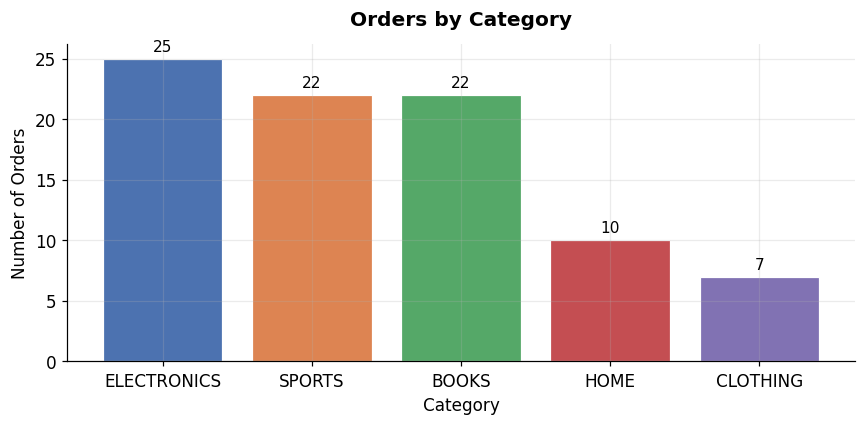

In [57]:
category_counts = df["Category"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(category_counts.index, category_counts.values,
              color=COLORS[:len(category_counts)], edgecolor="white", linewidth=0.8)
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_xlabel("Category")
ax.set_ylabel("Number of Orders")
ax.set_title("Orders by Category", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

### 2. Revenue by Category — Which category earns the most?

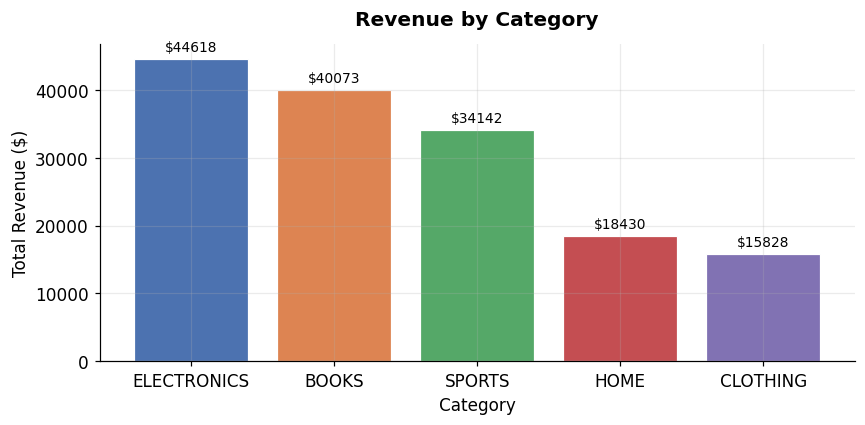

In [59]:
revenue_by_cat = df.groupby("Category")["Total"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(revenue_by_cat.index, revenue_by_cat.values,
              color=COLORS[:len(revenue_by_cat)], edgecolor="white", linewidth=0.8)
ax.bar_label(bars, fmt="$%.0f", padding=3, fontsize=9)
ax.set_xlabel("Category")
ax.set_ylabel("Total Revenue ($)")
ax.set_title("Revenue by Category", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

### 3. Monthly Sales Trend — How does revenue change over time?

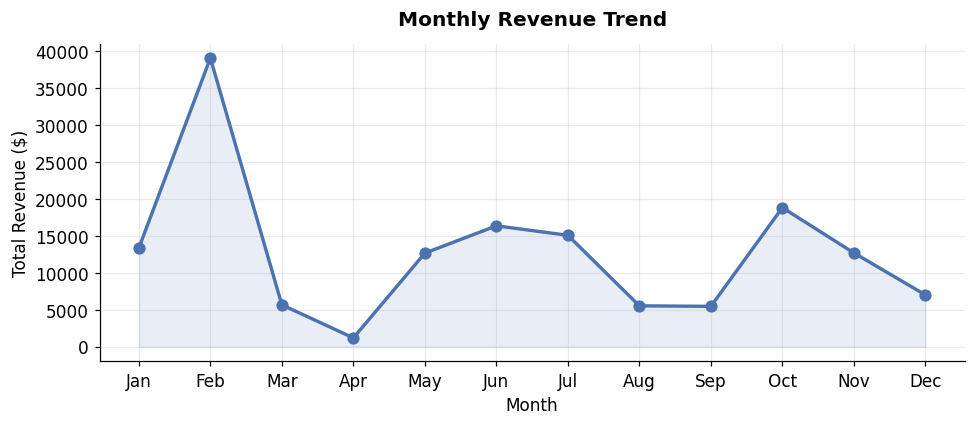

In [61]:
monthly_revenue = df.groupby("Month")["Total"].sum()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly_revenue.index, monthly_revenue.values,
        marker="o", color=COLORS[0], linewidth=2.2, markersize=7)
ax.fill_between(monthly_revenue.index, monthly_revenue.values, alpha=0.12, color=COLORS[0])
ax.set_xticks(monthly_revenue.index)
ax.set_xticklabels([month_labels[m-1] for m in monthly_revenue.index])
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue ($)")
ax.set_title("Monthly Revenue Trend", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

### 4. Payment Method Usage — How do customers prefer to pay?

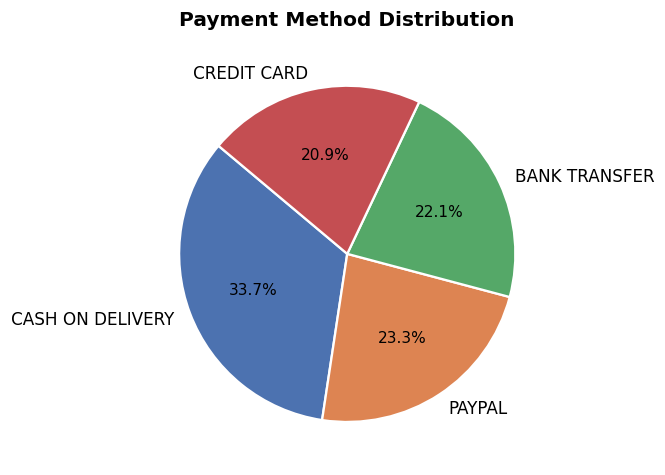

In [63]:
payment_counts = df["Payment_Method"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    colors=COLORS[:len(payment_counts)],
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
for t in autotexts:
    t.set_fontsize(10)
ax.set_title("Payment Method Distribution", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

### 5. Order Status — What is happening to orders?

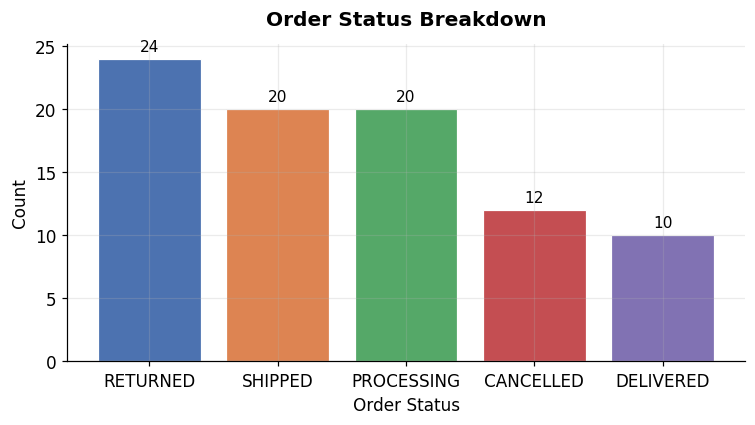

In [65]:
status_counts = df["Status"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(status_counts.index, status_counts.values,
              color=COLORS[:len(status_counts)], edgecolor="white", linewidth=0.8)
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_xlabel("Order Status")
ax.set_ylabel("Count")
ax.set_title("Order Status Breakdown", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

### 6. Top Selling Products — Which products move the most units?

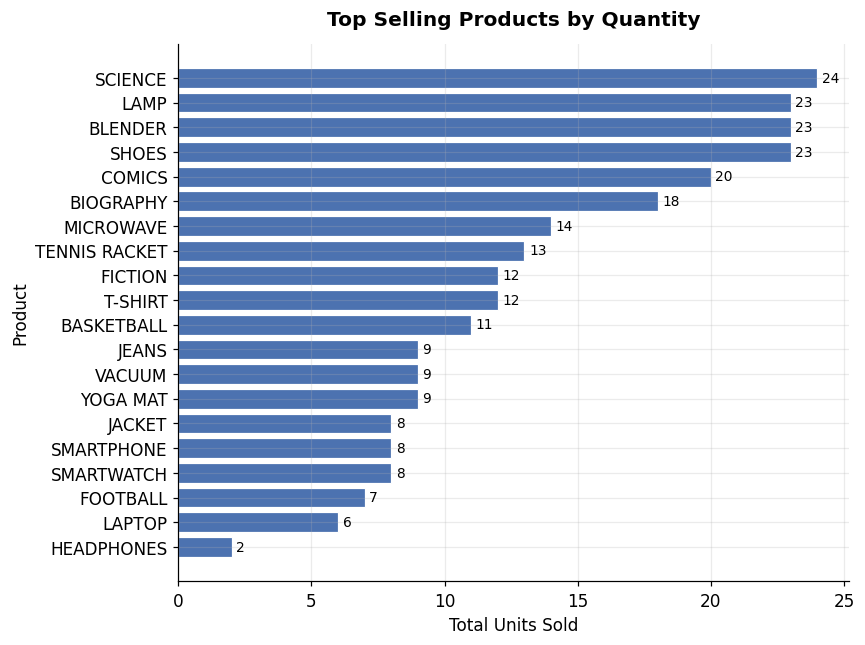

In [67]:
top_products = df.groupby("Product")["Quantity"].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top_products.index, top_products.values,
               color=COLORS[0], edgecolor="white", linewidth=0.8)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("Total Units Sold")
ax.set_ylabel("Product")
ax.set_title("Top Selling Products by Quantity", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

### 7. Revenue vs. Revenue Lost to Returns

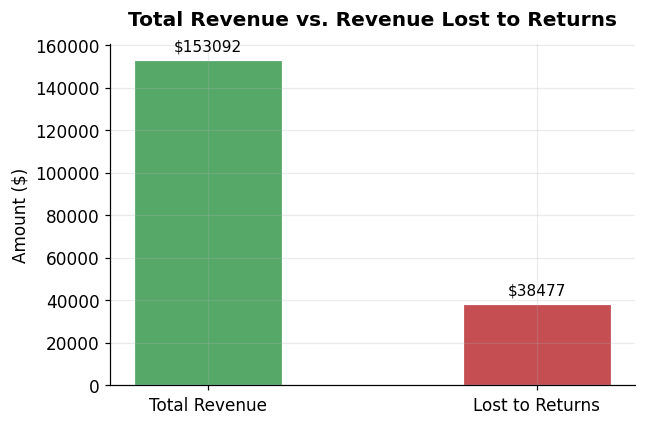

In [69]:
revenue_lost = df[df["Status"] == "RETURNED"]["Total"].sum()
total_rev    = df["Total"].sum()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Total Revenue", "Lost to Returns"], [total_rev, revenue_lost],
              color=[COLORS[2], COLORS[3]], edgecolor="white", linewidth=0.8, width=0.45)
ax.bar_label(bars, fmt="$%.0f", padding=4, fontsize=10)
ax.set_ylabel("Amount ($)")
ax.set_title("Total Revenue vs. Revenue Lost to Returns", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

### 8. Distribution of Order Values — Any outliers or skew?

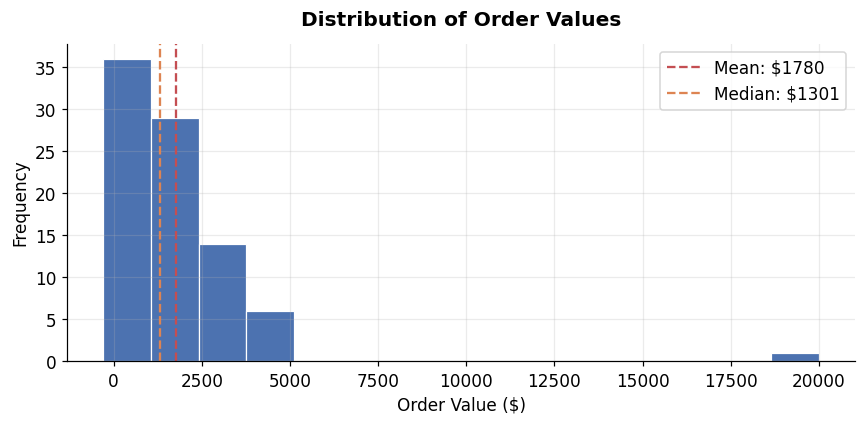

In [71]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["Total"], bins=15, color=COLORS[0], edgecolor="white", linewidth=0.8)
ax.axvline(df["Total"].mean(),   color=COLORS[3], linestyle="--", linewidth=1.5, label=f'Mean: ${df["Total"].mean():.0f}')
ax.axvline(df["Total"].median(), color=COLORS[1], linestyle="--", linewidth=1.5, label=f'Median: ${df["Total"].median():.0f}')
ax.set_xlabel("Order Value ($)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Order Values", fontweight="bold", pad=12)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Key Insights & Business Recommendations

| # | Insight | Recommendation |
|---|---|---|
| 1 | **Electronics** leads in revenue despite the same order count as Books | Prioritise electronics stock and promotions — highest revenue per order |
| 2 | **Cash on Delivery** is the dominant payment method | Ensure reliable COD fulfilment; consider incentives to shift customers to prepaid methods to reduce return risk |
| 3 | **Return rate** is significant — ~$38,000 in lost revenue | Investigate which products/categories drive the most returns; improve product descriptions or quality checks |
| 4 | **February** has the highest sales; **April** the lowest | Plan inventory and marketing campaigns around these seasonal patterns |
| 5 | **Science Fiction Books** and **Blenders** are top sellers by quantity | Consider bundling or cross-selling strategies around these products |
| 6 | **Clothing** underperforms in both order count and revenue | Review pricing, variety, or marketing for the clothing category |